# Technical Assignment: Mall Footfall Data Analysis

This notebook reproduces the assignment analysis across all four tasks:

1. Traffic model calibration (sensor data -> estimated real footfall)
2. Sensor intersection / overlap analysis
3. Journey reconstruction
4. Anomaly and pattern analysis

It is designed to run in the same workspace as `run_assignment_analysis.py` and supports two modes:

- **Full recomputation** from raw CSV files
- **Fast load** from precomputed outputs in `outputs/`

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from run_assignment_analysis import (
    load_data,
    task1_calibration,
    task2_sensor_intersection,
    task3_journeys,
    task4_anomalies,
    task4_advanced_anomalies,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.style.use("ggplot")

In [2]:
WORKSPACE_ROOT = Path("/Users/zohaibsarwar/Assignment Folder")
OUTPUT_DIR = WORKSPACE_ROOT / "outputs"

SESSION_CSV = Path("/Users/zohaibsarwar/Downloads/allunite_device_session.csv")
FACILITY_CSV = Path("/Users/zohaibsarwar/Downloads/facility_information - Sheet1.csv")
MANUAL_CSV = Path("/Users/zohaibsarwar/Downloads/Manual Counting - Sheet1.csv")

for p in [SESSION_CSV, FACILITY_CSV, MANUAL_CSV]:
    print(f"{p.name}: {'FOUND' if p.exists() else 'MISSING'}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs directory: {OUTPUT_DIR}")

allunite_device_session.csv: FOUND
facility_information - Sheet1.csv: FOUND
Manual Counting - Sheet1.csv: FOUND
Outputs directory: /Users/zohaibsarwar/Assignment Folder/outputs


## Run Analysis (full or fast mode)

Set `RUN_FULL_ANALYSIS`:

- `True` -> recompute from raw CSVs (takes longer)
- `False` -> load existing files from `outputs/` (fast)

In [3]:
RUN_FULL_ANALYSIS = True

# Safety guard: allow running this cell even if setup cells were skipped.
if "OUTPUT_DIR" not in globals():
    from pathlib import Path

    WORKSPACE_ROOT = Path("/Users/zohaibsarwar/Assignment Folder")
    OUTPUT_DIR = WORKSPACE_ROOT / "outputs"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if RUN_FULL_ANALYSIS:
    sessions, facilities, manuals = load_data()

    calibration_df, cal_result, hourly_footfall = task1_calibration(sessions, manuals)
    pair_counts, intersection_summary = task2_sensor_intersection(sessions, facilities)
    top_paths, transitions, sample_paths, total_journey_devices = task3_journeys(sessions, facilities)
    suspicious_devices, anomaly_hours, anomaly_summary = task4_anomalies(sessions, hourly_footfall)

    (
        matrix_profile_df,
        matrix_profile_detail,
        stl_df,
        iso_df,
        markov_journey_df,
        markov_hour_df,
        anomaly_comparison_df,
        advanced_anomaly_summary,
    ) = task4_advanced_anomalies(sessions, hourly_footfall, anomaly_hours)

    calibration_df.to_csv(OUTPUT_DIR / "task1_calibration_windows.csv", index=False)
    hourly_footfall.to_csv(OUTPUT_DIR / "task1_hourly_estimated_footfall.csv", index=False)
    pair_counts.to_csv(OUTPUT_DIR / "task2_sensor_overlap_pairs.csv", index=False)
    top_paths.head(100).to_csv(OUTPUT_DIR / "task3_top_journeys.csv", index=False)
    transitions.to_csv(OUTPUT_DIR / "task3_transition_matrix.csv", index=False)
    sample_paths.to_csv(OUTPUT_DIR / "task3_sample_device_journeys.csv", index=False)

    suspicious_devices.head(200).to_csv(OUTPUT_DIR / "task4_suspicious_unflagged_devices.csv", index=False)
    anomaly_hours.to_csv(OUTPUT_DIR / "task4_hourly_anomalies.csv", index=False)
    matrix_profile_df.to_csv(OUTPUT_DIR / "task4_matrix_profile_anomalies.csv", index=False)
    matrix_profile_detail.to_csv(OUTPUT_DIR / "task4_matrix_profile_details.csv", index=False)
    stl_df.to_csv(OUTPUT_DIR / "task4_stl_anomalies.csv", index=False)
    iso_df.to_csv(OUTPUT_DIR / "task4_isolation_forest_anomalies.csv", index=False)
    markov_journey_df.to_csv(OUTPUT_DIR / "task4_markov_journey_anomalies.csv", index=False)
    markov_hour_df.to_csv(OUTPUT_DIR / "task4_markov_hourly_anomalies.csv", index=False)
    anomaly_comparison_df.to_csv(OUTPUT_DIR / "task4_anomaly_comparison.csv", index=False)

    daily_estimates = (
        hourly_footfall.assign(date=lambda df: df["hour_start"].dt.date)
        .groupby("date", as_index=False)["estimated_total_footfall"]
        .sum()
        .sort_values("date")
    )

    summary = {
        "task1": {
            "selected_feature": cal_result.feature_name,
            "intercept": cal_result.intercept,
            "slope": cal_result.slope,
            "mae": cal_result.mae,
            "mape": cal_result.mape,
            "r2": cal_result.r2,
            "calibration_windows": int(len(calibration_df)),
        },
        "task2": intersection_summary,
        "task3": {
            "devices_with_multifacility_paths": total_journey_devices,
            "sampled_journeys_exported": int(len(sample_paths)),
            "top_path": top_paths.iloc[0]["path"] if len(top_paths) else None,
            "top_path_devices": int(top_paths.iloc[0]["device_count"]) if len(top_paths) else 0,
        },
        "task4": anomaly_summary,
        "task4_advanced": advanced_anomaly_summary,
        "daily_estimated_footfall": daily_estimates.to_dict(orient="records"),
    }

    with (OUTPUT_DIR / "analysis_summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, default=str)
else:
    calibration_df = pd.read_csv(OUTPUT_DIR / "task1_calibration_windows.csv")
    hourly_footfall = pd.read_csv(OUTPUT_DIR / "task1_hourly_estimated_footfall.csv", parse_dates=["hour_start"])
    pair_counts = pd.read_csv(OUTPUT_DIR / "task2_sensor_overlap_pairs.csv")
    top_paths = pd.read_csv(OUTPUT_DIR / "task3_top_journeys.csv")
    transitions = pd.read_csv(OUTPUT_DIR / "task3_transition_matrix.csv")
    sample_paths = pd.read_csv(OUTPUT_DIR / "task3_sample_device_journeys.csv")

    suspicious_devices = pd.read_csv(OUTPUT_DIR / "task4_suspicious_unflagged_devices.csv")
    anomaly_hours = pd.read_csv(OUTPUT_DIR / "task4_hourly_anomalies.csv", parse_dates=["hour_start"])
    matrix_profile_df = pd.read_csv(OUTPUT_DIR / "task4_matrix_profile_anomalies.csv", parse_dates=["hour_start"])
    matrix_profile_detail = pd.read_csv(OUTPUT_DIR / "task4_matrix_profile_details.csv", parse_dates=["hour_start"])
    stl_df = pd.read_csv(OUTPUT_DIR / "task4_stl_anomalies.csv", parse_dates=["hour_start"])
    iso_df = pd.read_csv(OUTPUT_DIR / "task4_isolation_forest_anomalies.csv", parse_dates=["hour_start"])
    markov_journey_df = pd.read_csv(OUTPUT_DIR / "task4_markov_journey_anomalies.csv", parse_dates=["start_time", "end_time", "end_hour_start"])
    markov_hour_df = pd.read_csv(OUTPUT_DIR / "task4_markov_hourly_anomalies.csv", parse_dates=["hour_start"])
    anomaly_comparison_df = pd.read_csv(OUTPUT_DIR / "task4_anomaly_comparison.csv", parse_dates=["hour_start"])

    with (OUTPUT_DIR / "analysis_summary.json").open("r", encoding="utf-8") as f:
        summary = json.load(f)

print("Loaded/created all task outputs.")
summary

/Users/zohaibsarwar/Assignment Folder/run_assignment_analysis.py:818: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison[col] = comparison[col].fillna(False).astype(bool)


Loaded/created all task outputs.


{'task1': {'selected_feature': 'trusted_unique_devices',
  'intercept': 516.9755907556479,
  'slope': 2.3495196052973246,
  'mae': 17.014541677486335,
  'mape': 0.029670876338133256,
  'r2': 0.7996709821219614,
  'calibration_windows': 4},
 'task2': {'total_unique_devices_clean': 2042923,
  'multi_sensor_devices': 131320,
  'multi_sensor_rate': 0.06428044522480779},
 'task3': {'devices_with_multifacility_paths': 131320,
  'sampled_journeys_exported': 200,
  'top_path': '66330 -> 66331',
  'top_path_devices': 42826},
 'task4': {'high_session_threshold_top_0_1pct': 32.0,
  'suspicious_unflagged_devices': 87,
  'is_excluded': 0.001054046805904619,
  'is_anomaly': 0.0,
  'is_fake': 2.7129474751131542e-05,
  'flagged_any': 0.0010811762806557505},
 'task4_advanced': {'matrix_profile_anomaly_hours': 56,
  'stl_anomaly_hours': 51,
  'isolation_forest_anomaly_hours': 51,
  'markov_journey_anomalies': 3953,
  'markov_hour_anomalies': 37,
  'consensus_anomaly_hours': 29,
  'max_method_agreement_c

## Task 1 — Traffic Model: Estimate Real Visitor Count

In [4]:
task1 = summary["task1"]
print("Selected feature:", task1["selected_feature"])
print("Model: estimated = intercept + slope * feature")
print(f"intercept={task1['intercept']:.3f}, slope={task1['slope']:.4f}")
print(f"MAE={task1['mae']:.2f}, MAPE={task1['mape']*100:.2f}%, R2={task1['r2']:.3f}")

calibration_df[[
    "facility_num",
    "started",
    "manual_total_count",
    task1["selected_feature"],
    "estimated_total_count",
]].sort_values(["facility_num", "started"])

Selected feature: trusted_unique_devices
Model: estimated = intercept + slope * feature
intercept=516.976, slope=2.3495
MAE=17.01, MAPE=2.97%, R2=0.800


,facility_num,started,manual_total_count,trusted_unique_devices,estimated_total_count
0,66330,2026-04-23 13:00:00+00:00,651.0,52.0,639.150610
1,66330,2026-04-24 13:00:00+00:00,550.0,18.0,559.266944
2,66333,2026-04-23 15:00:00+00:00,565.0,11.0,542.820306
3,66333,2026-04-24 15:00:00+00:00,558.0,28.0,582.762140


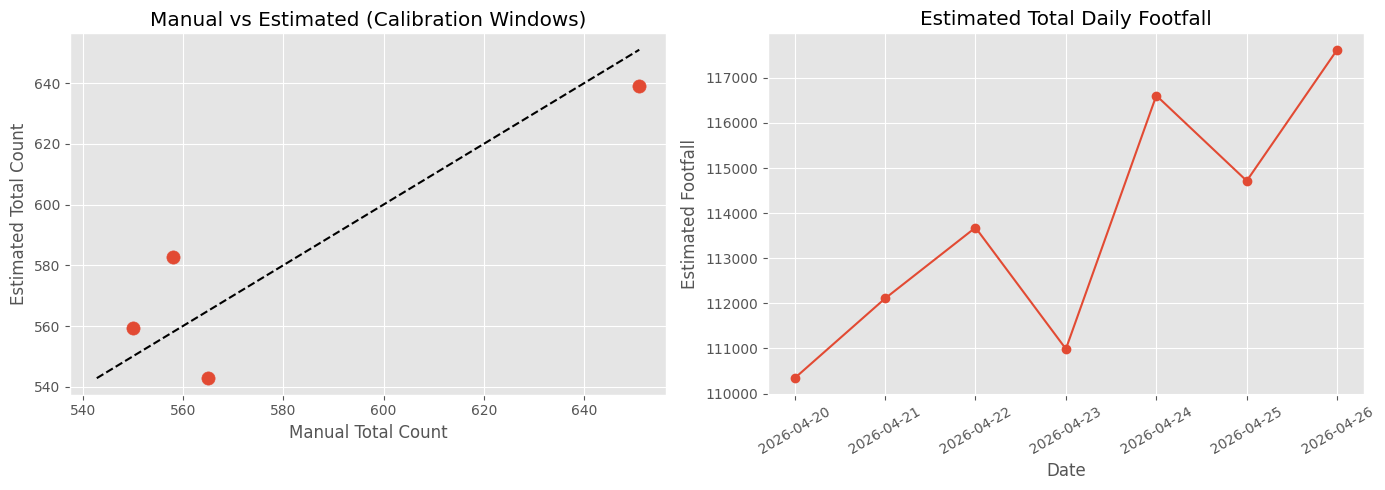

,date,estimated_total_footfall
0,2026-04-20,110340.73
1,2026-04-21,112108.21
2,2026-04-22,113679.91
3,2026-04-23,110989.30
4,2026-04-24,116607.37
5,2026-04-25,114715.54
6,2026-04-26,117622.50


In [5]:
# Visual checks for calibration and full-week trend.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(calibration_df["manual_total_count"], calibration_df["estimated_total_count"], s=90)
mn = min(calibration_df["manual_total_count"].min(), calibration_df["estimated_total_count"].min())
mx = max(calibration_df["manual_total_count"].max(), calibration_df["estimated_total_count"].max())
axes[0].plot([mn, mx], [mn, mx], linestyle="--", color="black")
axes[0].set_title("Manual vs Estimated (Calibration Windows)")
axes[0].set_xlabel("Manual Total Count")
axes[0].set_ylabel("Estimated Total Count")

daily = (
    hourly_footfall.assign(date=lambda df: pd.to_datetime(df["hour_start"]).dt.date)
    .groupby("date", as_index=False)["estimated_total_footfall"]
    .sum()
)
axes[1].plot(daily["date"], daily["estimated_total_footfall"], marker="o")
axes[1].set_title("Estimated Total Daily Footfall")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Estimated Footfall")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

daily

## Task 2 — Sensor Intersection: Devices Seen by Multiple Sensors

In [6]:
task2 = summary["task2"]
print("Total clean unique devices:", f"{task2['total_unique_devices_clean']:,}")
print("Devices seen by >1 sensor:", f"{task2['multi_sensor_devices']:,}")
print("Multi-sensor rate:", f"{task2['multi_sensor_rate']*100:.2f}%")

top_overlap = pair_counts.sort_values("shared_devices", ascending=False).head(10)
top_overlap[[
    "facility_name_x",
    "facility_name_y",
    "shared_devices",
    "jaccard_overlap",
    "overlap_pct_smaller_side",
]]

Total clean unique devices: 2,042,923
Devices seen by >1 sensor: 131,320
Multi-sensor rate: 6.43%


,facility_name_x,facility_name_y,shared_devices,jaccard_overlap,overlap_pct_smaller_side
0,GB-LVO-DD-08003,GB-LVO-DD-08005,58355,0.102625,0.274803
25,GB-LVO-DD-08009,GB-LVO-DD-08023,43278,0.105286,0.356344
35,GB-LVO-DD-08021,GB-LVO-DD-08023,8926,0.012513,0.026814
20,GB-LVO-DD-08007,GB-LVO-DD-08023,7334,0.013665,0.034733
26,GB-LVO-DD-08013,GB-LVO-DD-08015,7318,0.014490,0.028864
1,GB-LVO-DD-08003,GB-LVO-DD-08007,5468,0.008815,0.025896
31,GB-LVO-DD-08015,GB-LVO-DD-08021,5156,0.008084,0.020336
8,GB-LVO-DD-08005,GB-LVO-DD-08007,4925,0.011766,0.023324
7,GB-LVO-DD-08003,GB-LVO-DD-08023,4290,0.005772,0.012887
24,GB-LVO-DD-08009,GB-LVO-DD-08021,4120,0.008131,0.033923


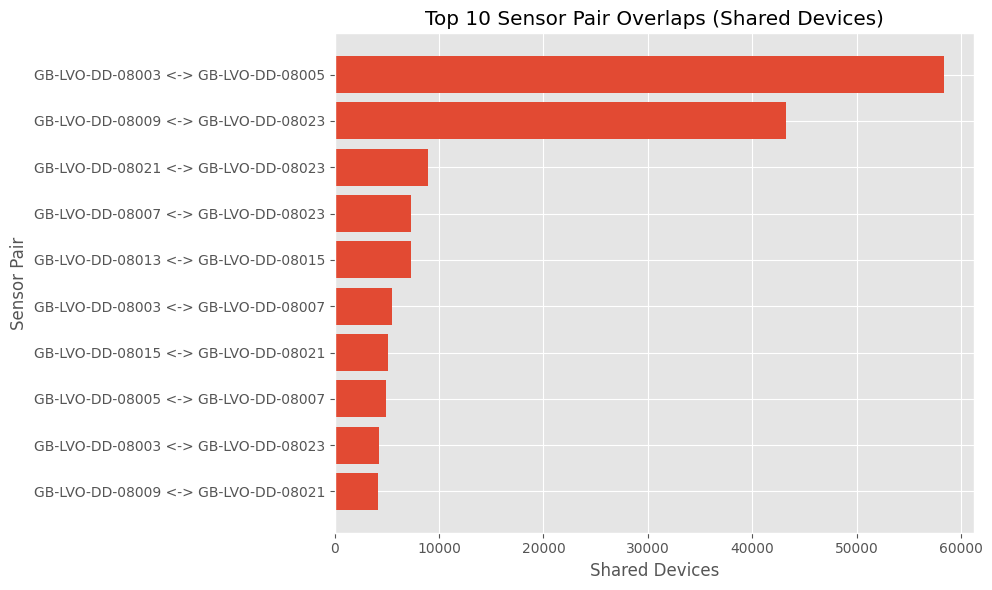

In [7]:
plot_df = pair_counts.sort_values("shared_devices", ascending=True).tail(10).copy()
plot_df["pair"] = plot_df["facility_name_x"] + " <-> " + plot_df["facility_name_y"]

plt.figure(figsize=(10, 6))
plt.barh(plot_df["pair"], plot_df["shared_devices"])
plt.title("Top 10 Sensor Pair Overlaps (Shared Devices)")
plt.xlabel("Shared Devices")
plt.ylabel("Sensor Pair")
plt.tight_layout()
plt.show()

## Task 3 — Journey Mapping: Reconstruct Visitor Paths

In [8]:
task3 = summary["task3"]
print("Devices with multi-facility paths:", f"{task3['devices_with_multifacility_paths']:,}")
print("Top path:", task3["top_path"])
print("Top path devices:", f"{task3['top_path_devices']:,}")

print("\nTop journey templates:")
display(top_paths.head(15))

print("Top transitions:")
display(transitions.head(15))

Devices with multi-facility paths: 131,320
Top path: 66330 -> 66331
Top path devices: 42,826

Top journey templates:


,path,device_count,path_length
0,66330 -> 66331,42826,2
2145,66333 -> 66342,30510,2
1021,66331 -> 66330,7212,2
4271,66342 -> 66333,6898,2
2523,66335 -> 66336,2964,2
1831,66332 -> 66342,2778,2
4591,66342 -> 66340,2534,2
2944,66336 -> 66335,1730,2
3903,66340 -> 66342,1626,2
3103,66336 -> 66340,1529,2


Top transitions:


,facility_num,next_facility,transition_count,facility_name_from,facility_name_to
0,66330,66331,51395,GB-LVO-DD-08003,GB-LVO-DD-08005
1,66333,66342,34547,GB-LVO-DD-08009,GB-LVO-DD-08023
2,66331,66330,11532,GB-LVO-DD-08005,GB-LVO-DD-08003
3,66342,66333,10090,GB-LVO-DD-08023,GB-LVO-DD-08009
4,66342,66340,4954,GB-LVO-DD-08023,GB-LVO-DD-08021
5,66335,66336,4775,GB-LVO-DD-08013,GB-LVO-DD-08015
6,66332,66342,4340,GB-LVO-DD-08007,GB-LVO-DD-08023
7,66340,66342,3674,GB-LVO-DD-08021,GB-LVO-DD-08023
8,66336,66335,3299,GB-LVO-DD-08015,GB-LVO-DD-08013
9,66336,66340,2990,GB-LVO-DD-08015,GB-LVO-DD-08021


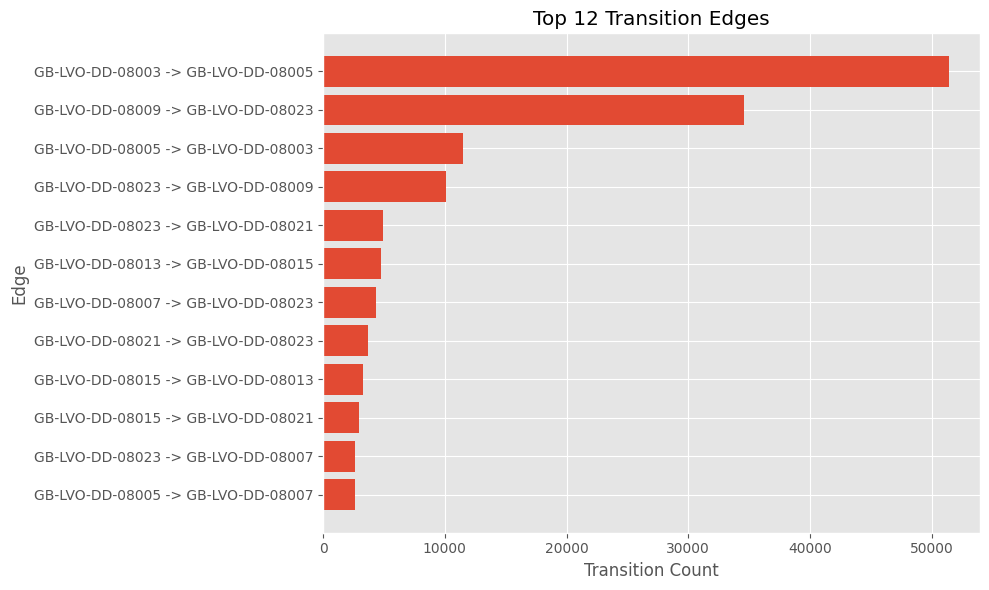

In [9]:
trans_plot = transitions.sort_values("transition_count", ascending=True).tail(12).copy()
trans_plot["edge"] = trans_plot["facility_name_from"] + " -> " + trans_plot["facility_name_to"]

plt.figure(figsize=(10, 6))
plt.barh(trans_plot["edge"], trans_plot["transition_count"])
plt.title("Top 12 Transition Edges")
plt.xlabel("Transition Count")
plt.ylabel("Edge")
plt.tight_layout()
plt.show()

## Task 4 — Advanced Anomaly Detection & Pattern Analysis

This section compares five complementary detectors:

- **Baseline z-score**: unusually high/low estimated footfall per facility
- **Matrix Profile**: discord detection for unusual time-series shapes (6h/12h/24h windows)
- **STL residual score**: outliers after trend + seasonal decomposition
- **Isolation Forest**: multivariate outliers from hourly traffic features
- **Markov journey score**: unlikely visitor path transitions

In [10]:
task4 = summary["task4"]
print("Flag rates in sessions:")
print(f"- is_excluded: {task4['is_excluded']*100:.4f}%")
print(f"- is_anomaly: {task4['is_anomaly']*100:.4f}%")
print(f"- is_fake: {task4['is_fake']*100:.4f}%")
print(f"- flagged_any: {task4['flagged_any']*100:.4f}%")
print(f"- suspicious unflagged devices: {task4['suspicious_unflagged_devices']:,}")

adv = summary.get("task4_advanced", {})
method_summary = pd.DataFrame([
    {"method": "baseline_zscore", "anomaly_count": int(anomaly_hours["is_anomaly_hour"].sum())},
    {"method": "matrix_profile", "anomaly_count": int(matrix_profile_df["is_matrix_profile_anomaly"].sum())},
    {"method": "stl_residual", "anomaly_count": int(stl_df["is_stl_anomaly"].sum())},
    {"method": "isolation_forest", "anomaly_count": int(iso_df["is_isolation_forest_anomaly"].sum())},
    {"method": "markov_journey", "anomaly_count": int(markov_journey_df["is_markov_journey_anomaly"].sum())},
    {"method": "consensus_hourly", "anomaly_count": int(anomaly_comparison_df["is_consensus_anomaly"].sum())},
])

print("\nAdvanced method counts (from current run):")
if adv:
    print(adv)

display(method_summary)
print("\nSample suspicious unflagged devices:")
suspicious_devices.head(10)

Flag rates in sessions:
- is_excluded: 0.1054%
- is_anomaly: 0.0000%
- is_fake: 0.0027%
- flagged_any: 0.1081%
- suspicious unflagged devices: 87

Advanced method counts (from current run):
{'matrix_profile_anomaly_hours': 56, 'stl_anomaly_hours': 51, 'isolation_forest_anomaly_hours': 51, 'markov_journey_anomalies': 3953, 'markov_hour_anomalies': 37, 'consensus_anomaly_hours': 29, 'max_method_agreement_count': 4}


,method,anomaly_count
0,baseline_zscore,25
1,matrix_profile,56
2,stl_residual,51
3,isolation_forest,51
4,markov_journey,3953
5,consensus_hourly,29



Sample suspicious unflagged devices:


,device_id,total_sessions,unique_facilities,active_days,night_sessions,flagged_sessions,permanent_device,night_session_ratio
301405,-6494026690822609217,250,2,7,76,0,False,0.304000
1585676,5088077912193283307,162,1,7,42,0,False,0.259259
277269,-6711644857162113724,159,1,7,49,0,False,0.308176
903729,-1060597035815568323,158,1,7,46,0,False,0.291139
1112664,829460662524800544,154,8,7,0,0,False,0.000000
1632445,5511101531531910734,121,7,7,0,0,False,0.000000
1254371,2103817626303511229,118,3,7,0,0,False,0.000000
1866143,7619055922795575219,111,7,5,0,0,False,0.000000
299759,-6508696305285198635,109,1,7,0,0,False,0.000000
1930388,8197388559519492513,93,8,4,0,0,False,0.000000


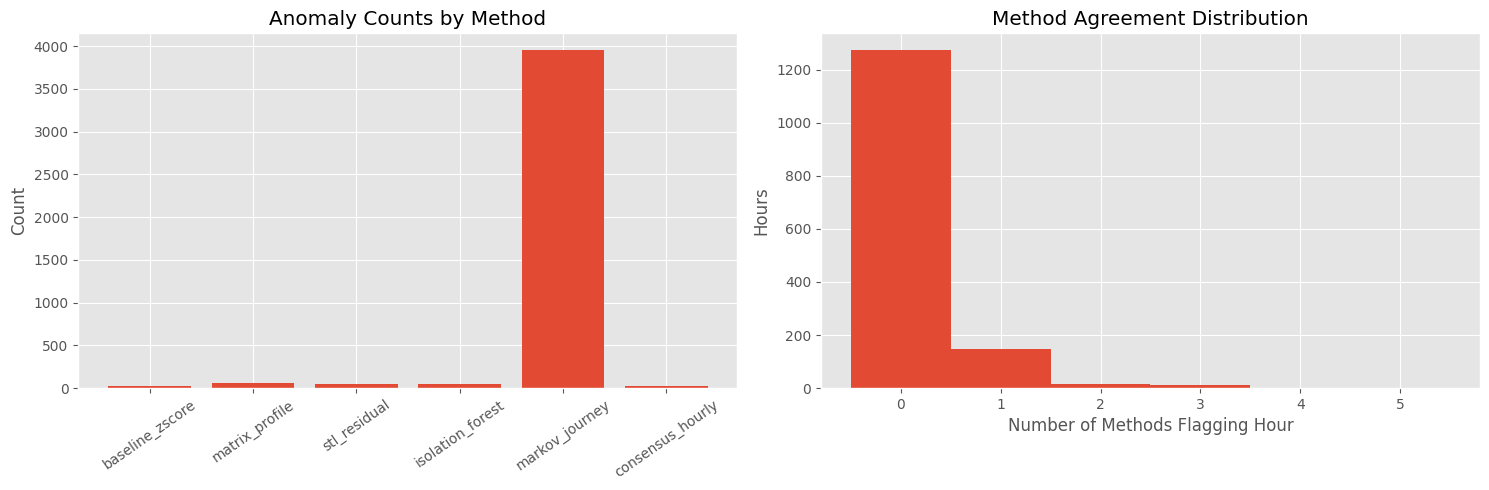

Top consensus hourly events:


,facility_num,hour_start,estimated_total_footfall,ensemble_score,method_agreement_count,is_consensus_anomaly,is_anomaly_hour,is_matrix_profile_anomaly,is_stl_anomaly,is_isolation_forest_anomaly,is_markov_hour_anomaly
1045,66338,2026-04-22 15:00:00+00:00,528.72,0.636828,4,True,True,False,True,True,True
1033,66338,2026-04-21 20:00:00+00:00,528.72,0.531263,2,True,True,False,True,False,False
637,66333,2026-04-25 13:00:00+00:00,679.09,0.500749,2,True,True,False,False,True,False
1016,66338,2026-04-20 21:00:00+00:00,526.37,0.494125,1,False,False,False,True,False,False
1251,66340,2026-04-25 15:00:00+00:00,733.13,0.461760,3,True,True,False,True,True,False
329,66331,2026-04-26 17:00:00+00:00,627.40,0.458173,2,True,True,False,False,True,False
1249,66340,2026-04-25 13:00:00+00:00,726.08,0.456496,3,True,True,False,True,True,False
88,66330,2026-04-23 16:00:00+00:00,672.04,0.455502,3,True,True,False,True,True,False
327,66331,2026-04-26 15:00:00+00:00,608.61,0.429023,3,True,True,False,True,True,False
1250,66340,2026-04-25 14:00:00+00:00,711.99,0.425956,3,True,True,False,True,True,False


Top Markov journey anomalies:


,device_id,start_time,end_time,start_facility,end_facility,path_steps,markov_score,rare_transition_ratio,path
85409,2778332381181807829,2026-04-25 14:52:39+00:00,2026-04-26 06:07:15+00:00,66333,66338,2,652.766716,1.0,66333 -> 66338
121979,7910173827973510697,2026-04-21 11:59:32+00:00,2026-04-26 20:48:40+00:00,66330,66338,2,572.520885,1.0,66330 -> 66338
55494,-1457143807736140267,2026-04-21 19:40:14+00:00,2026-04-21 22:37:16+00:00,66330,66338,2,572.520885,1.0,66330 -> 66338
86738,2962744600501277145,2026-04-23 22:52:57+00:00,2026-04-26 16:05:55+00:00,66330,66338,2,572.520885,1.0,66330 -> 66338
125034,8325354597839977385,2026-04-25 10:52:33+00:00,2026-04-26 08:32:40+00:00,66330,66338,2,572.520885,1.0,66330 -> 66338
58213,-1080806417116210431,2026-04-24 16:27:17+00:00,2026-04-26 16:14:08+00:00,66340,66338,2,512.166608,1.0,66340 -> 66338
71962,875234390866264801,2026-04-25 15:26:05+00:00,2026-04-26 23:21:25+00:00,66340,66338,2,512.166608,1.0,66340 -> 66338
96968,4397356558801126308,2026-04-21 14:59:05+00:00,2026-04-24 10:44:34+00:00,66340,66338,2,512.166608,1.0,66340 -> 66338
13971,-7239101322964842997,2026-04-22 12:40:14+00:00,2026-04-26 15:55:40+00:00,66340,66338,2,512.166608,1.0,66340 -> 66338
110309,6276633042099272235,2026-04-21 08:48:16+00:00,2026-04-24 11:01:25+00:00,66340,66338,2,512.166608,1.0,66340 -> 66338


In [11]:
consensus_top = anomaly_comparison_df.sort_values("ensemble_score", ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(method_summary["method"], method_summary["anomaly_count"])
axes[0].set_title("Anomaly Counts by Method")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=35)

axes[1].hist(anomaly_comparison_df["method_agreement_count"], bins=np.arange(0, 7) - 0.5)
axes[1].set_title("Method Agreement Distribution")
axes[1].set_xlabel("Number of Methods Flagging Hour")
axes[1].set_ylabel("Hours")
axes[1].set_xticks(range(0, 6))

plt.tight_layout()
plt.show()

print("Top consensus hourly events:")
display(
    consensus_top[
        [
            "facility_num",
            "hour_start",
            "estimated_total_footfall",
            "ensemble_score",
            "method_agreement_count",
            "is_consensus_anomaly",
            "is_anomaly_hour",
            "is_matrix_profile_anomaly",
            "is_stl_anomaly",
            "is_isolation_forest_anomaly",
            "is_markov_hour_anomaly",
        ]
    ]
)

print("Top Markov journey anomalies:")
if len(markov_journey_df):
    display(
        markov_journey_df.sort_values("markov_score", ascending=False).head(15)[
            [
                "device_id",
                "start_time",
                "end_time",
                "start_facility",
                "end_facility",
                "path_steps",
                "markov_score",
                "rare_transition_ratio",
                "path",
            ]
        ]
    )
else:
    print("No Markov journey anomalies found in current run.")

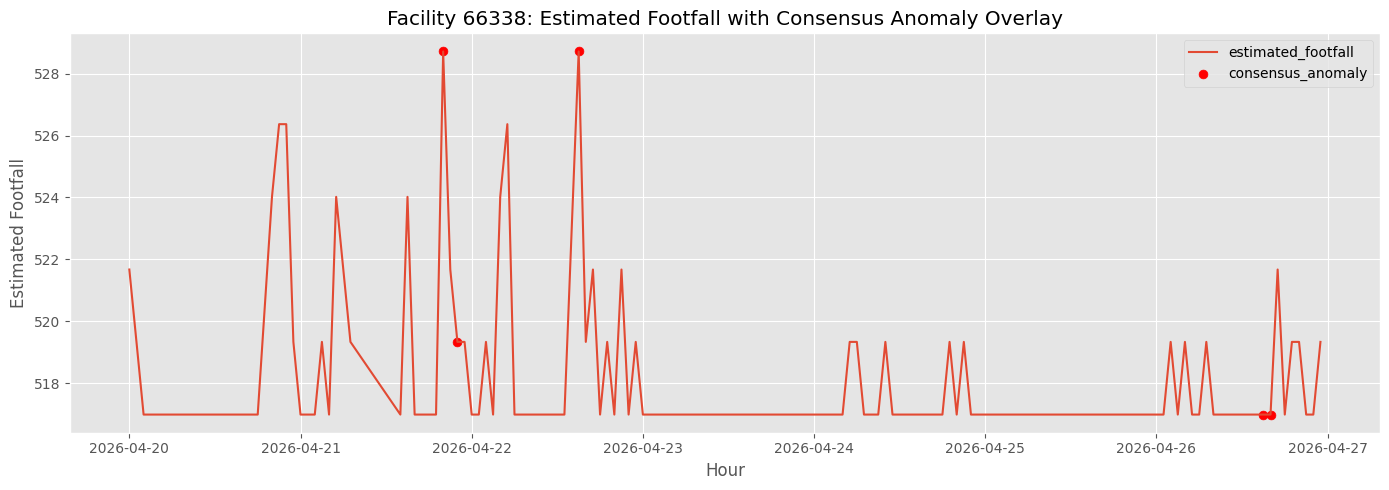

In [12]:
# Per-facility timeline overlay for consensus anomalies.
fac = int(anomaly_comparison_df.sort_values("ensemble_score", ascending=False).iloc[0]["facility_num"])
plot_df = anomaly_comparison_df.loc[anomaly_comparison_df["facility_num"] == fac].sort_values("hour_start").copy()

plt.figure(figsize=(14, 5))
plt.plot(plot_df["hour_start"], plot_df["estimated_total_footfall"], label="estimated_footfall")
cons = plot_df.loc[plot_df["is_consensus_anomaly"]]
plt.scatter(cons["hour_start"], cons["estimated_total_footfall"], color="red", s=40, label="consensus_anomaly")
plt.title(f"Facility {fac}: Estimated Footfall with Consensus Anomaly Overlay")
plt.xlabel("Hour")
plt.ylabel("Estimated Footfall")
plt.legend()
plt.tight_layout()
plt.show()

## Benchmark — Which Anomaly Method Performs Best?

This benchmark compares methods using **proxy labels** (because true anomaly labels are unavailable):

- **Contamination proxy**: high rate of flagged/noisy sessions in the hour
- **Temporal shock proxy**: large hour-to-hour footfall change
- Metrics used: `AUC`, `Average Precision`, and `Precision@K`

The benchmark files are generated in `outputs/` as:

- `task4_method_benchmark.csv`
- `task4_method_overlap_jaccard.csv`

In [13]:
benchmark_df = pd.read_csv(OUTPUT_DIR / "task4_method_benchmark.csv")
overlap_df = pd.read_csv(OUTPUT_DIR / "task4_method_overlap_jaccard.csv", index_col=0)

# Fair ranking: proxy-only metrics (exclude consensus-driven metrics).
proxy_cols = [
    "auc_contam",
    "ap_contam",
    "p_at_k_contam",
    "auc_shock",
    "ap_shock",
    "p_at_k_shock",
]
rank_df = benchmark_df.copy()
for col in proxy_cols:
    lo, hi = rank_df[col].min(), rank_df[col].max()
    rank_df[f"{col}_norm"] = 0.0 if hi <= lo else (rank_df[col] - lo) / (hi - lo)
rank_df["proxy_composite_score"] = rank_df[[f"{c}_norm" for c in proxy_cols]].mean(axis=1)
rank_df = rank_df.sort_values("proxy_composite_score", ascending=False)

display_cols = [
    "method",
    "flagged_hours",
    "proxy_composite_score",
    "auc_contam",
    "ap_contam",
    "auc_shock",
    "ap_shock",
]
print("Proxy benchmark ranking (higher is better):")
display(rank_df[display_cols].reset_index(drop=True))

Proxy benchmark ranking (higher is better):


,method,flagged_hours,proxy_composite_score,auc_contam,ap_contam,auc_shock,ap_shock
0,isolation_forest,51,0.645833,0.507317,0.030141,0.820999,0.130346
1,zscore,25,0.609154,0.506752,0.034340,0.692698,0.110664
2,stl_residual,51,0.587515,0.426778,0.052964,0.563743,0.054423
3,markov_hour,37,0.478002,0.065387,0.030324,0.817862,0.116970
4,matrix_profile,56,0.283800,0.498304,0.041574,0.436577,0.028907


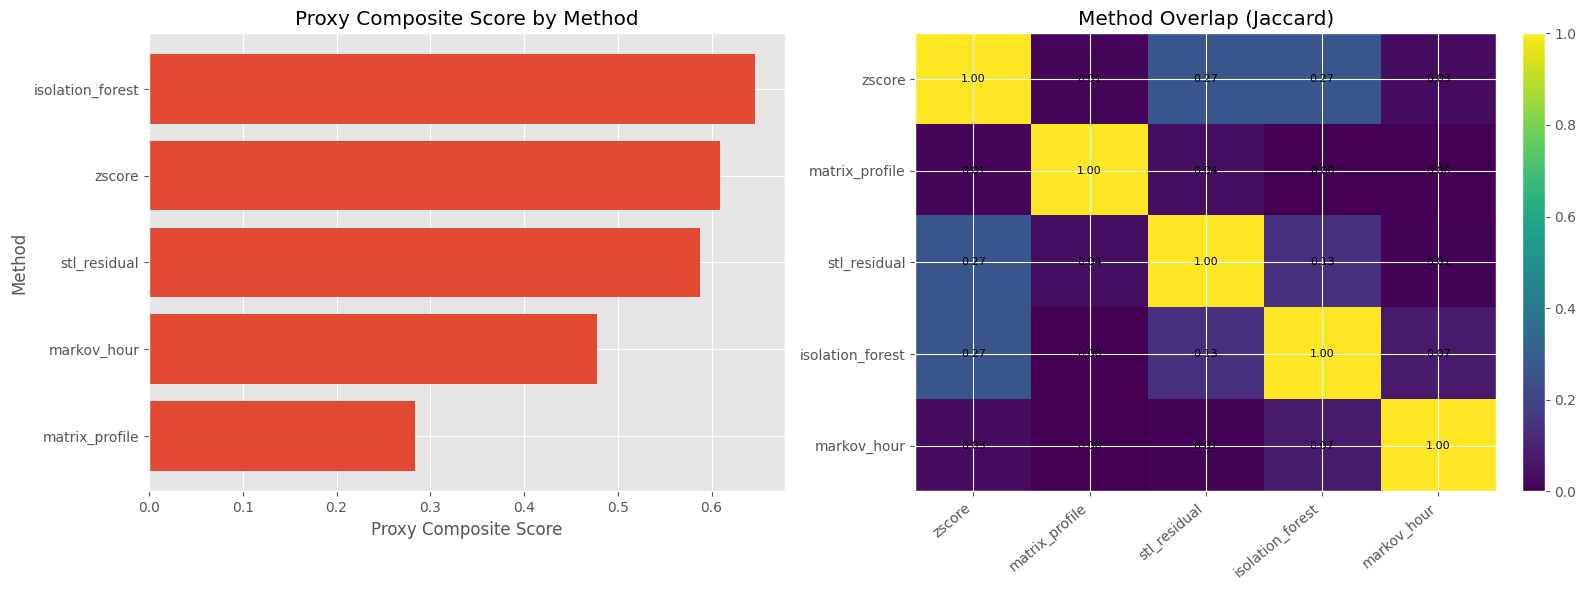

Best method on proxy benchmark: isolation_forest (score=0.646)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ranking bar chart
plot_rank = rank_df.sort_values("proxy_composite_score", ascending=True)
axes[0].barh(plot_rank["method"], plot_rank["proxy_composite_score"])
axes[0].set_title("Proxy Composite Score by Method")
axes[0].set_xlabel("Proxy Composite Score")
axes[0].set_ylabel("Method")

# Overlap heatmap (Jaccard)
heat = overlap_df.to_numpy(dtype=float)
im = axes[1].imshow(heat, aspect="auto")
axes[1].set_xticks(range(len(overlap_df.columns)))
axes[1].set_yticks(range(len(overlap_df.index)))
axes[1].set_xticklabels(overlap_df.columns, rotation=40, ha="right")
axes[1].set_yticklabels(overlap_df.index)
axes[1].set_title("Method Overlap (Jaccard)")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        axes[1].text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

best_method = rank_df.iloc[0]["method"]
best_score = rank_df.iloc[0]["proxy_composite_score"]
print(f"Best method on proxy benchmark: {best_method} (score={best_score:.3f})")

## Final Notes

- This notebook mirrors the script workflow and produces the same outputs.
- It now includes a dedicated benchmark section comparing anomaly methods with transparent proxy metrics.
- For submission, pair this notebook with `ASSIGNMENT_REPORT.md` and the CSVs in `outputs/`.
- When the floor plan image is provided, Task 3 transitions can be overlaid spatially as the next step.